# SARP FireAlarm Tutorial 

#### This notebook goes in depth into the code used to achieve some of the analysis and visualization examples in the SARP_demo.ipynb notebook.

The notebook walks through how to do things like data discovery, query for data from FireAlarm, and work with the data returned from a query. Some of the cells make use of code that has been abstracted into functions in the `sarp_demo_tools.py` file, particularly for some of the mapping cells. The functions in that script contain docstrings (a string at the top of a function that documents the purpose of the function) as well as comments in the code explaining in greater detail what is happening. We encourage you to check out that code if you're interested.

There are instructions in `README.md` for installing the dependencies required to execute these notebooks.

*NOTE about cell execution times:* 

- The initiale exeuction of the import cell may take up to a few minutes to complete.
- Pulling data from FireAlarm makes use of a local cache mechanism. The first time the data is requested can take a few seconds, but subsuquent requests should be immediate.
- Mapping cells can take around 20 seconds or so to execute due to the amount of data being mapped.

In [1]:
# Data processing libraries
import numpy as np
import pandas as pd
import requests
from datetime import datetime

# Plotting and mapping libraries
import folium
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from branca.colormap import LinearColormap

# Library containing custom code
import sarp_demo_tools
from sarp_demo_tools import data_request

## Data Discovery or seeing what SARP data is available

This URL provides a listing of SARP data ingested into the FireAlarm platform. 

You can open it in a browser, but we want to perform some actions on the information provided at the URL, so we'll make use of Python's `requests` library to programatically access the URL.

In [2]:
SARP_COLLECTIONS_URL = "https://ideas-digitaltwin.jpl.nasa.gov/insitu/1.0/sub_collection_statistics?provider=SARP&project=air_quality"

requests.get() returns a response which includes more than just what's visible on the browser. We load the URL's content via the response.json() function. 

The contents are loaded into Python as nested lists and dictionaries. 

### Query for all SARP collections ingested into the system

In [3]:
resp = requests.get(SARP_COLLECTIONS_URL)
sarp_collections_data = resp.json()
sarp_collections_data

{'providers': [{'provider': 'SARP',
   'projects': [{'project': 'air_quality',
     'platforms': [{'platform': 'DA-B-200FX-aircraft--WINDS-TAMMS',
       'platform_short_name': 'unknown',
       'total': 95423.0,
       'lat': 39.655519,
       'lon': -75.125951,
       'min_datetime': '2025-06-22T16:24:51Z',
       'max_datetime': '2025-07-02T18:21:14Z',
       'observation_counts': {'Qout': 0.0,
        'pm2_5': 0.0,
        'bc': 0.0,
        'no2': 0.0,
        'co': 0.0,
        'co2': 0.0,
        'no': 0.0,
        'o3': 0.0,
        'pressure': 0.0,
        'pm1': 0.0,
        'pm10': 0.0,
        'pm25': 0.0,
        'Streamflow': 0.0,
        'Gage_height': 0.0,
        'Stream_water_level_elevation_above_NAVD_1988': 0.0,
        'Lake_or_reservoir_water_surface_elevation_above_NAVD_1988': 0.0,
        'RelativeHumidity': 0.0,
        'RelativeHumidity_Ice': 0.0,
        'Temperature': 0.0,
        'distance_along_leg': 0.0,
        'friction_velocity': 0.0,
        'convecti

We navigate through it to get to the "platforms" section which contains the information we're interested in. This will be a list of dictionaries.

In [4]:
sarp_collections_data = sarp_collections_data['providers'][0]['projects'][0]['platforms']
sarp_collections_data

[{'platform': 'DA-B-200FX-aircraft--WINDS-TAMMS',
  'platform_short_name': 'unknown',
  'total': 95423.0,
  'lat': 39.655519,
  'lon': -75.125951,
  'min_datetime': '2025-06-22T16:24:51Z',
  'max_datetime': '2025-07-02T18:21:14Z',
  'observation_counts': {'Qout': 0.0,
   'pm2_5': 0.0,
   'bc': 0.0,
   'no2': 0.0,
   'co': 0.0,
   'co2': 0.0,
   'no': 0.0,
   'o3': 0.0,
   'pressure': 0.0,
   'pm1': 0.0,
   'pm10': 0.0,
   'pm25': 0.0,
   'Streamflow': 0.0,
   'Gage_height': 0.0,
   'Stream_water_level_elevation_above_NAVD_1988': 0.0,
   'Lake_or_reservoir_water_surface_elevation_above_NAVD_1988': 0.0,
   'RelativeHumidity': 0.0,
   'RelativeHumidity_Ice': 0.0,
   'Temperature': 0.0,
   'distance_along_leg': 0.0,
   'friction_velocity': 0.0,
   'convective_velocity_scale': 0.0,
   'sensible_heat_flux': 0.0,
   'latent_heat_flux': 0.0,
   'co2_flux': 0.0,
   'ch4_flux': 0.0,
   'obukhov_length': 0.0,
   'gps_altitude': 95423.0,
   'pressure_altitude': 0.0,
   'radar_altitude': 0.0,
   'p

### Filter collections

Next, we want to filter this to just the information relevant to SARP.

We do this by loading the list of dictionaries as a Pandas DataFrame data structure, which will convert to a tabular form.

In [5]:
sarp_collections_df = pd.DataFrame(sarp_collections_data)
sarp_collections_df.sort_values("max_datetime", ascending=False)

,platform,platform_short_name,total,lat,lon,min_datetime,max_datetime,observation_counts,units,min_depth,max_depth
12,Dynamic-Aviation-King-Air-(N46L)--PICARRO-GHG,unknown,411047.0,38.579780,0.000000,2025-06-30T14:36:21Z,2025-07-07T17:50:42Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
0,DA-B-200FX-aircraft--WINDS-TAMMS,unknown,95423.0,39.655519,-75.125951,2025-06-22T16:24:51Z,2025-07-02T18:21:14Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
3,Dynamic-Aviation-B200--CAFE-CH2O,unknown,31638.0,39.511965,-75.144285,2025-06-23T14:04:54Z,2025-07-02T18:21:12Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
5,Dynamic-Aviation-B200--CANOE-NO2,unknown,40998.0,39.655519,-75.125951,2025-06-22T14:12:45Z,2025-07-02T18:21:12Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
7,Dynamic-Aviation-B200--ROZE-O3,unknown,89532.0,39.655519,-75.125951,2025-06-22T16:36:27Z,2025-07-02T18:21:11Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
11,Dynamic-Aviation-King-Air-(N46L)--GHG-FLUX,unknown,25851.0,39.512000,-75.126000,2025-06-22T19:03:56Z,2025-06-29T23:03:52Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
13,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG,unknown,43211.0,39.668883,0.000000,2025-06-22T16:55:32Z,2025-06-29T23:03:51Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
31,Wallops-P-3-N426NA--MetNav,unknown,83996.0,39.982979,-75.204430,2024-07-02T16:05:49Z,2025-06-25T17:11:50Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
20,"NASA-P3,-N426NA--LARGE-MICROPHYSICAL",unknown,60643.0,39.982979,-75.204430,2024-07-02T16:06:24Z,2025-06-25T17:08:20Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
23,"NASA-P3,-N426NA--LARGE-UHSAS",unknown,43821.0,39.982979,-75.204430,2025-06-23T13:07:18Z,2025-06-25T17:08:20Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None


That's much easier to look at. Next we do some manipulation on the `observation_counts` and corresponding `units` fields to clean them up.

In [6]:
# Filter irrelevant variables
sarp_collections_df['observation_counts'] = sarp_collections_df['observation_counts'].apply(lambda d: {k: v for k, v in d.items() if v > 0})
sarp_collections_df['units'] = sarp_collections_df.apply(lambda row: {k: row['units'].get(k) for k in row['observation_counts'].keys()}, axis=1)
collections_df = sarp_collections_df[[c for c in sarp_collections_df.columns if "depth" not in c and c != "platform_short_name"]]
collections_df.head()

,platform,total,lat,lon,min_datetime,max_datetime,observation_counts,units
0,DA-B-200FX-aircraft--WINDS-TAMMS,95423.0,39.655519,-75.125951,2025-06-22T16:24:51Z,2025-07-02T18:21:14Z,{'gps_altitude': 95423.0},{'gps_altitude': 'm'}
1,Dynamic-Aviation-B-200-aircraft--WINDS-fast-DA,8450.0,34.116150,-117.477290,2024-07-03T01:11:24Z,2024-07-03T01:18:26Z,"{'pressure': 8450.0, 'RelativeHumidity': 8450....","{'pressure': 'hPa', 'RelativeHumidity': '%', '..."
2,Dynamic-Aviation-B-200-aircraft--WINDS-slow-DA,26924.0,34.442456,-115.268470,2024-07-02T14:48:43Z,2024-07-03T01:18:26Z,"{'pressure': 26924.0, 'RelativeHumidity': 2692...","{'pressure': 'hPa', 'RelativeHumidity': '%', '..."
3,Dynamic-Aviation-B200--CAFE-CH2O,31638.0,39.511965,-75.144285,2025-06-23T14:04:54Z,2025-07-02T18:21:12Z,"{'gps_altitude': 31610.0, 'ch2o_cafe': 31638.0}","{'gps_altitude': 'm', 'ch2o_cafe': 'ppt'}"
4,Dynamic-Aviation-B200--CAFE-CH2O-DA,4280.0,34.134946,-117.196270,2024-07-03T00:05:32Z,2024-07-03T01:16:51Z,{'ch2o_cafe': 4280.0},{'ch2o_cafe': 'ppt'}


And now we can see the variables available for each platform (campaign) along with some information about the spatial and temporal extents.

In [7]:
altitude_collections = sarp_collections_df[sarp_collections_df["observation_counts"].apply(lambda d: any("alt" in k for k in d.keys()))]
altitude_collections

,platform,platform_short_name,total,lat,lon,min_datetime,max_datetime,observation_counts,units,min_depth,max_depth
0,DA-B-200FX-aircraft--WINDS-TAMMS,unknown,95423.0,39.655519,-75.125951,2025-06-22T16:24:51Z,2025-07-02T18:21:14Z,{'gps_altitude': 95423.0},{'gps_altitude': 'm'},None,None
1,Dynamic-Aviation-B-200-aircraft--WINDS-fast-DA,unknown,8450.0,34.116150,-117.477290,2024-07-03T01:11:24Z,2024-07-03T01:18:26Z,"{'pressure': 8450.0, 'RelativeHumidity': 8450....","{'pressure': 'hPa', 'RelativeHumidity': '%', '...",None,None
2,Dynamic-Aviation-B-200-aircraft--WINDS-slow-DA,unknown,26924.0,34.442456,-115.268470,2024-07-02T14:48:43Z,2024-07-03T01:18:26Z,"{'pressure': 26924.0, 'RelativeHumidity': 2692...","{'pressure': 'hPa', 'RelativeHumidity': '%', '...",None,None
3,Dynamic-Aviation-B200--CAFE-CH2O,unknown,31638.0,39.511965,-75.144285,2025-06-23T14:04:54Z,2025-07-02T18:21:12Z,"{'gps_altitude': 31610.0, 'ch2o_cafe': 31638.0}","{'gps_altitude': 'm', 'ch2o_cafe': 'ppt'}",None,None
5,Dynamic-Aviation-B200--CANOE-NO2,unknown,40998.0,39.655519,-75.125951,2025-06-22T14:12:45Z,2025-07-02T18:21:12Z,"{'no2': 40998.0, 'gps_altitude': 40251.0}","{'no2': 'ppb', 'gps_altitude': 'm'}",None,None
7,Dynamic-Aviation-B200--ROZE-O3,unknown,89532.0,39.655519,-75.125951,2025-06-22T16:36:27Z,2025-07-02T18:21:11Z,"{'o3': 89532.0, 'gps_altitude': 42474.0}","{'o3': 'ppb', 'gps_altitude': 'm'}",None,None
11,Dynamic-Aviation-King-Air-(N46L)--GHG-FLUX,unknown,25851.0,39.512000,-75.126000,2025-06-22T19:03:56Z,2025-06-29T23:03:52Z,"{'distance_along_leg': 25851.0, 'friction_velo...","{'distance_along_leg': 'm', 'friction_velocity...",None,None
12,Dynamic-Aviation-King-Air-(N46L)--PICARRO-GHG,unknown,411047.0,38.579780,0.000000,2025-06-30T14:36:21Z,2025-07-07T17:50:42Z,"{'co': 28516.0, 'co2': 411047.0, 'gps_altitude...","{'co': 'ppm', 'co2': 'ppm', 'gps_altitude': 'm...",None,None
13,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG,unknown,43211.0,39.668883,0.000000,2025-06-22T16:55:32Z,2025-06-29T23:03:51Z,"{'co': 24853.0, 'co2': 43211.0, 'gps_altitude'...","{'co': 'ppm', 'co2': 'ppm', 'gps_altitude': 'm...",None,None
14,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...,unknown,4737.0,34.060111,-117.481794,2024-07-03T01:13:46Z,2024-07-03T01:21:40Z,"{'co2': 4737.0, 'gps_altitude': 4737.0, 'ch4':...","{'co2': 'ppm', 'gps_altitude': 'm', 'ch4': 'pp...",None,None


## Querying for Data from Fire Alarm

### PICARRO Greenhouse Gases

In [8]:
altitude_collections[altitude_collections["platform"] == "Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-SLOW-DA"]

,platform,platform_short_name,total,lat,lon,min_datetime,max_datetime,observation_counts,units,min_depth,max_depth
15,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...,unknown,6790.0,34.313596,-117.195605,2024-07-02T20:49:51Z,2024-07-03T01:21:38Z,"{'co': 6790.0, 'co2': 6790.0, 'gps_altitude': ...","{'co': 'ppm', 'co2': 'ppm', 'gps_altitude': 'm...",None,None


We'll make use of a different URL to query for data. We'll define some parameters that will be passed to the URL in order to retrieve results specific to our parameters.

In [9]:
# We specify one of the SARP campaigns from the "platform" column in our collections dataframe
platform = "Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-SLOW-DA"

# We specify the time bounds for which we want data as datetime objects
start_time = datetime(2024,7,2)
end_time = datetime(2024,7,4)

# We define a bounding box string in the format:
# "min_lon,min_lat,max_lon,max_lat"
bounding_box = "-118.75,33.5,-115,34.25"

# Query for the data using the data_request function in sarp_demo_tools.py
PICARRO_GHG_SLOW_df = data_request(platform, start_time, end_time, bounding_box)
PICARRO_GHG_SLOW_df

,latitude,longitude,co,co2,gps_altitude,ch4,water_vapor,provider,platform
time,,,,,,,,,
2024-07-02 20:53:25+00:00,34.249944,-118.657569,0.2337,438.946,1111.250650,2.07344,13443.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:27+00:00,34.248500,-118.657885,0.2171,438.870,1111.011997,2.07429,14650.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:29+00:00,34.246922,-118.658236,0.2286,438.607,1110.126551,2.07423,14609.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:31+00:00,34.245417,-118.658560,0.2280,438.652,1108.087739,2.07213,13206.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:33+00:00,34.243921,-118.658876,0.2217,438.109,1106.665285,2.07072,13023.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
...,...,...,...,...,...,...,...,...,...
2024-07-03 01:21:30+00:00,34.051883,-117.612010,-9.9990,-9999.000,311.800000,-9999.00000,-9999.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-03 01:21:32+00:00,34.051883,-117.612010,-9.9990,-9999.000,311.800000,-9999.00000,-9999.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-03 01:21:34+00:00,34.051883,-117.612010,-9.9990,-9999.000,311.800000,-9999.00000,-9999.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...


There's a few tweaks to make. We can see there are -9999.0 fill values. Let's replace them with NaNs or "Not a Number" which let's us know there is missing data.

In [10]:
# Replace fill values with nans
# These variables have a fill value of -9999.0
nan_cals = ["co2", "ch4", "water_vapor"]
PICARRO_GHG_SLOW_df[nan_cals] = PICARRO_GHG_SLOW_df[nan_cals].replace(-9999.0, np.nan)

# CO has been converted to ppm during ingestion, so it's "fill value" is -9.999
PICARRO_GHG_SLOW_df["co"] = PICARRO_GHG_SLOW_df["co"].replace(-9.999, np.nan)

# We then drop the rows that contain NaN in any of the columns
PICARRO_GHG_SLOW_df = PICARRO_GHG_SLOW_df.dropna(axis=0, how="any")

PICARRO_GHG_SLOW_df

,latitude,longitude,co,co2,gps_altitude,ch4,water_vapor,provider,platform
time,,,,,,,,,
2024-07-02 20:53:25+00:00,34.249944,-118.657569,0.2337,438.946,1111.250650,2.07344,13443.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:27+00:00,34.248500,-118.657885,0.2171,438.870,1111.011997,2.07429,14650.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:29+00:00,34.246922,-118.658236,0.2286,438.607,1110.126551,2.07423,14609.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:31+00:00,34.245417,-118.658560,0.2280,438.652,1108.087739,2.07213,13206.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-02 20:53:33+00:00,34.243921,-118.658876,0.2217,438.109,1106.665285,2.07072,13023.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
...,...,...,...,...,...,...,...,...,...
2024-07-03 01:16:24+00:00,34.056732,-117.581827,0.2341,441.530,366.220253,2.03782,16780.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-03 01:16:26+00:00,34.056740,-117.583291,0.2340,440.614,357.159742,2.03845,16793.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...
2024-07-03 01:16:28+00:00,34.056746,-117.584684,0.2257,440.620,351.257701,2.03685,16796.0,SARP,Dynamic-Aviation-King-Air-(N87Q)--PICARRO-GHG-...


We can use the `map_picarro_ghg()` function in sarp_demo_tools to make a Folio map with multiple selectable layers

In [ ]:
sarp_demo_tools.map_picarro_ghg(PICARRO_GHG_SLOW_df)

We can also use the `plot_picarro_ghg()` function to do a timeseries analysis of the data

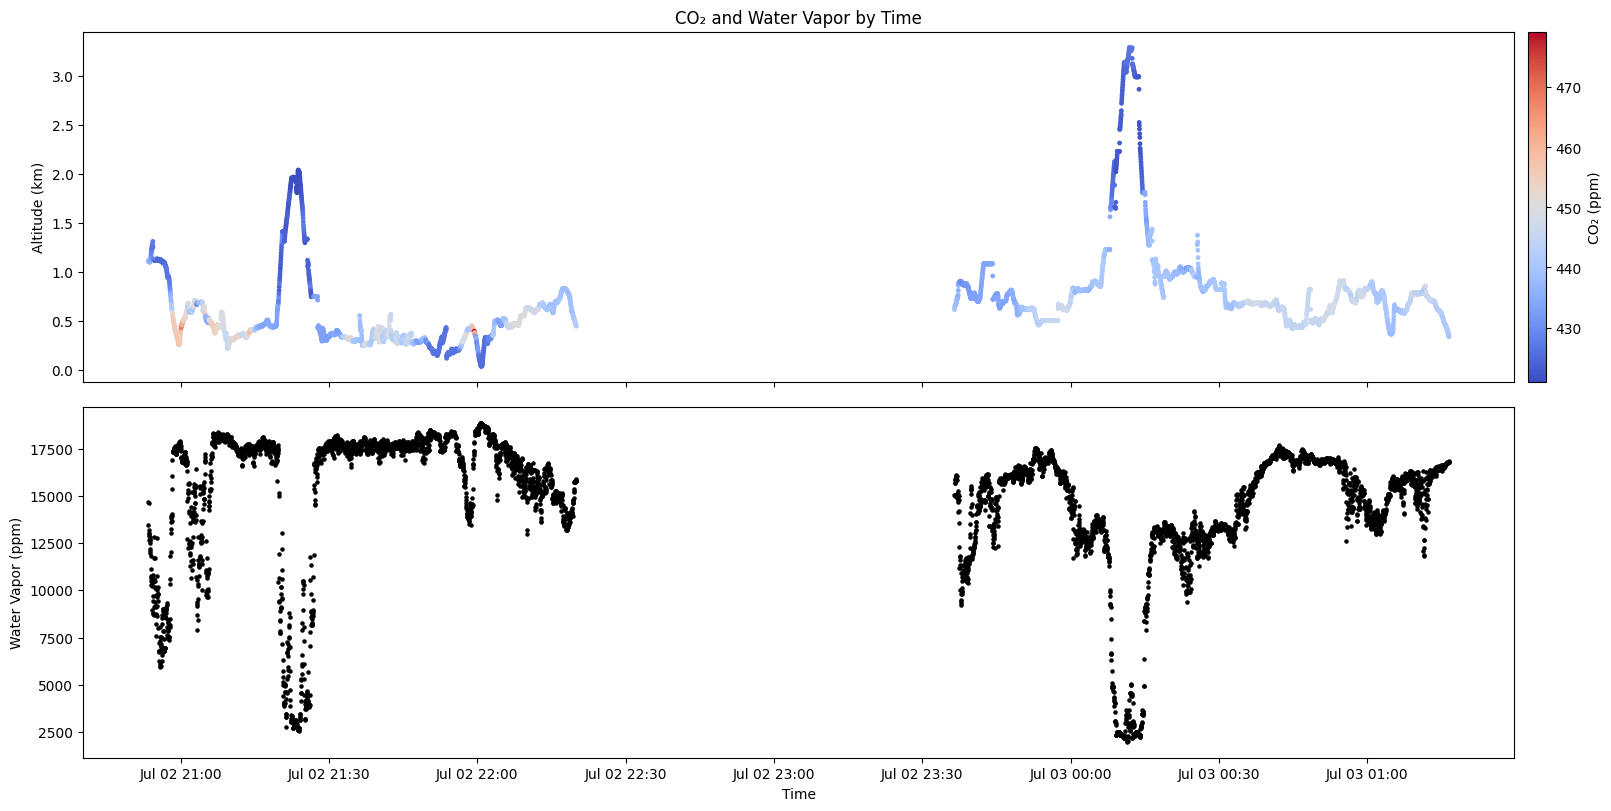

In [12]:
plot = sarp_demo_tools.plot_picarro_ghg(PICARRO_GHG_SLOW_df)

### ROZE O3

In [11]:
collections_df[collections_df["platform"] == "Dynamic-Aviation-B200--ROZE-O3-10Hz-DA"]

,platform,total,lat,lon,min_datetime,max_datetime,observation_counts,units
8,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA,288483.0,34.442456,-115.26847,2024-07-02T14:37:59Z,2024-07-03T01:16:50Z,{'o3': 288483.0},{'o3': 'ppb'}


Again we specify our query parameters and use the `data_request()` function to query Fire Alarm. We then clean up the data.

In [13]:
# Query specific parameters
platform = "Dynamic-Aviation-B200--ROZE-O3-10Hz-DA"
start_time = datetime(2024,7,2)
end_time = datetime(2024,7,4)
bounding_box = "-122,32,-114,38"

ROZE_O3_df = data_request(platform, start_time, end_time, bounding_box)
ROZE_O3_df["o3"] = ROZE_O3_df["o3"].replace(-9999.0, np.nan)
ROZE_O3_df = ROZE_O3_df.dropna(axis=0, how="any")
ROZE_O3_df

,latitude,longitude,o3,provider,platform
time,,,,,
2024-07-02 14:59:35+00:00,34.05690,-117.594111,17.82,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA
2024-07-02 14:59:36+00:00,34.05690,-117.594591,18.10,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA
2024-07-02 14:59:37+00:00,34.05690,-117.595090,18.01,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA
2024-07-02 14:59:38+00:00,34.05690,-117.595608,18.22,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA
2024-07-02 14:59:39+00:00,34.05690,-117.596152,17.84,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA
...,...,...,...,...,...
2024-07-03 01:16:45+00:00,34.05692,-117.594661,69.62,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA
2024-07-03 01:16:46+00:00,34.05692,-117.595287,69.53,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA
2024-07-03 01:16:47+00:00,34.05692,-117.595900,69.38,SARP,Dynamic-Aviation-B200--ROZE-O3-10Hz-DA


We can do a quick timeseries plot to view the data

Text(0, 0.5, 'O3 (ppb)')

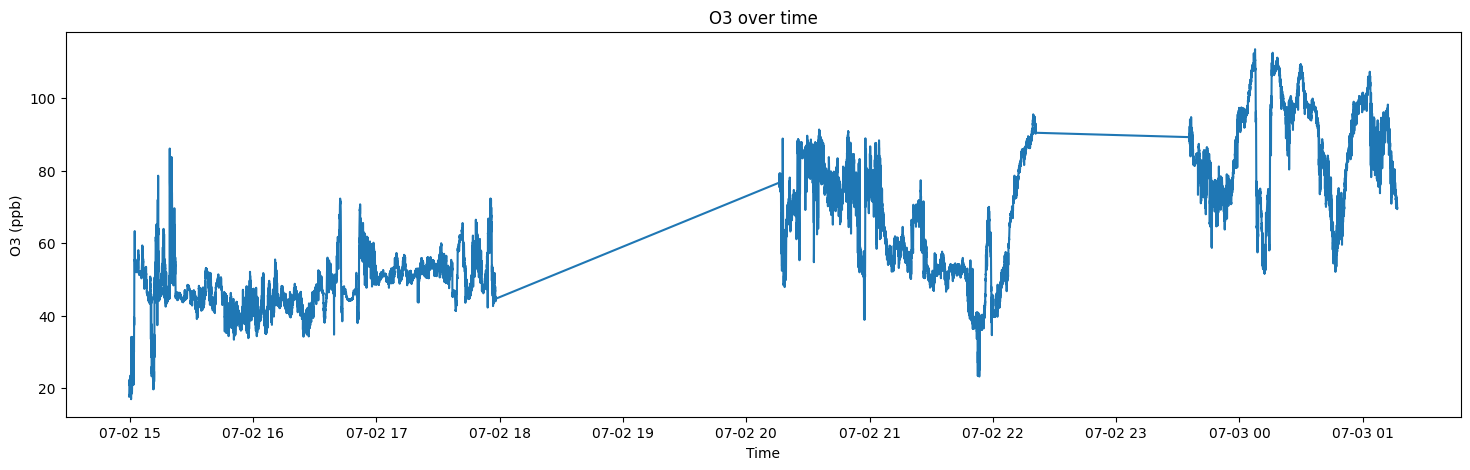

In [14]:
fig = plt.figure(figsize=(18,5))

plt.plot(pd.to_datetime(ROZE_O3_df.index), ROZE_O3_df['o3'])

plt.title('O3 over time')
plt.xlabel('Time')
plt.ylabel('O3 (ppb)')

Or view it on an interactive map

In [ ]:
# Create base map
m = folium.Map(location=[34, -117.9], zoom_start=10, tiles=None)

# Add satellite imagery layer from Esri
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles © Esri — Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, etc.',
    name='Esri Satellite',
    overlay=False,
    control=False
).add_to(m)

# Prepare data columns for mapping
latitudes = ROZE_O3_df['latitude'].values
longitudes = ROZE_O3_df['longitude'].values
o3_values = ROZE_O3_df['o3'].values
timestamps = ROZE_O3_df.index

# --- Time Layer ---

# Normalize time values for color mapping
timestamp_seconds = timestamps.astype('int64') // 10**9  # Convert to POSIX time
time_norm = colors.Normalize(vmin=timestamp_seconds.min(), vmax=timestamp_seconds.max())
time_colors = [colors.rgb2hex(cm.viridis(time_norm(t))) for t in timestamp_seconds]

time_layer = folium.FeatureGroup(name="Time Markers", show=True, overlay=False)

for lat, lon, time, time_color in zip(latitudes, longitudes, timestamps, time_colors):
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color=time_color,
        fill=True,
        fill_opacity=0.8,
        popup=pd.to_datetime(time).strftime('%b %d %H:%M:%S')
    ).add_to(time_layer)
    
# --- O3 Layer ---

# Normalize O3 values and map to colors
o3_norm = colors.Normalize(vmin=np.nanmin(o3_values), vmax=np.nanmax(o3_values))
o3_colors = [colors.rgb2hex(cm.magma(o3_norm(v))) for v in o3_values]

o3_layer = folium.FeatureGroup(name="O3 Markers", show=True, overlay=False)

# Add circle markers to each layer
for lat, lon, o3, color in zip(latitudes, longitudes, o3_values, o3_colors):
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"{o3:.1f} ppm"
    ).add_to(o3_layer)

# Add layers and controls to map
time_layer.add_to(m)
o3_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Display map
m

## Integration with other data

Fire Alarm includes other kinds of data as well. There are in-situ monitoring sites from AirNow as well as various gridded satellite datasets and model outputs. In addition to querying for the raw data itself, Fire Alarm can do its own analysis on satellite and model data through a variety of algorithms. 

### Data Discovery

Again we query to get a listing of ingested collections, this time for satellite and model data

In [15]:
resp = requests.get("https://ideas-digitaltwin.jpl.nasa.gov/nexus/list")
satellite_collections_data = resp.json()
satellite_collections_data

[{'shortName': 'oco3_sams_l3_fossil0005_pre_qf',
  'title': 'oco3_sams_l3_fossil0005_pre_qf',
  'type': 'zarr',
  'start': 1582574358,
  'end': 1742514327,
  'iso_start': '2020-02-24T19:59:18',
  'iso_end': '2025-03-20T23:45:27',
  'metadata': {'comment': 'NetCDF Lite files converted to Zarr (and/or Cloud-Optimized GeoTIFF) on fixed grid',
   'contacts': 'Riley Kuttruff <Riley.K.Kuttruff@jpl.nasa.gov>; Nga Chung <Nga.T.Chung@jpl.nasa.gov>; Abhishek Chatterjee <Abhishek.Chatterjee@jpl.nasa.gov>',
   'coverage_end': '2025-03-20T23:45:27Z',
   'coverage_start': '2020-02-24T19:59:18Z',
   'date_created': '2025-04-19T01:42:07Z',
   'date_updated': '2025-04-29T23:49:33Z',
   'institution': 'Jet Propulsion Laboratory',
   'interpolation_method': 'nearest',
   'operation_mode': 'Snapshot Area Mapping [SAM] + Target',
   'pipeline_version': '2025.4.14',
   'platform': 'ISS',
   'processing_level': 'L3',
   'quality_flag_filtered': 'no',
   'references': '10.5194/amt-12-2341-2019, 10.1016/j.rse.

Format the json response...

In [16]:
satellite_collections_df = pd.DataFrame(satellite_collections_data)
satellite_collections_df.head()

,shortName,title,type,start,end,iso_start,iso_end,metadata,tileCount,spatial_extent
0,oco3_sams_l3_fossil0005_pre_qf,oco3_sams_l3_fossil0005_pre_qf,zarr,1.582574e+09,1.742514e+09,2020-02-24T19:59:18,2025-03-20T23:45:27,{'comment': 'NetCDF Lite files converted to Za...,NaN,NaN
1,oco3_sams_l3_fossil0005_post_qf,oco3_sams_l3_fossil0005_post_qf,zarr,1.582574e+09,1.742514e+09,2020-02-24T19:59:18,2025-03-20T23:46:06,{'comment': 'NetCDF Lite files converted to Za...,NaN,NaN
2,oco3_sams_l3_post_qf,oco3_sams_l3_post_qf,zarr,1.565050e+09,1.699747e+09,2019-08-06T00:00:00,2023-11-12T00:00:00,{'comment': 'NetCDF Lite files converted to Za...,NaN,NaN
3,oco3_sams_l3_pre_qf,oco3_sams_l3_pre_qf,zarr,1.565050e+09,1.699747e+09,2019-08-06T00:00:00,2023-11-12T00:00:00,{'comment': 'NetCDF Lite files converted to Za...,NaN,NaN
4,AERDB_D3_VIIRS_SNPP_v2,AERDB_D3_VIIRS_SNPP_v2,nexusproto,1.330819e+09,1.330819e+09,2012-03-04T00:00:00+0000,2012-03-04T00:00:00+0000,NaN,67.0,"-179.50,-89.50,179.50,89.50"


Select the global TEMPO collections

In [17]:
tempo_collections = satellite_collections_df[satellite_collections_df["shortName"].str.contains("TEMPO")]
tempo_collections

,shortName,title,type,start,end,iso_start,iso_end,metadata,tileCount,spatial_extent
104,TEMPO_HCHO_L3_V03,TEMPO_HCHO_L3_V03,nexusproto,1.733575e+09,1.751897e+09,2024-12-07T12:36:18+0000,2025-07-07T14:11:28+0000,NaN,1009042.0,"-165.99,14.01,-18.01,67.99"
105,TEMPO_NO2_L3_V03,TEMPO_NO2_L3_V03,nexusproto,1.733575e+09,1.751897e+09,2024-12-07T12:36:18+0000,2025-07-07T14:11:28+0000,NaN,1036646.0,"-151.99,14.01,-28.01,65.99"
106,TEMPO_O3TOT_L3_V03,TEMPO_O3TOT_L3_V03,nexusproto,1.735649e+09,1.751905e+09,2024-12-31T12:47:51+0000,2025-07-07T16:11:28+0000,NaN,608275.0,"-163.99,14.01,-20.01,67.99"


### Combining TEMPO and SARP data on a Map

Here, we make use of one of Fire Alarm's algorithms for satellite data analysis: temporal average of gridded satellite data. We can use the response data to map the average of the satellite data over a given time window. We set some query parameters, format the response data, and map the gridded TEMPO O3 data along with the ROZE O3 flight data.

In [19]:
dataset_name = "TEMPO_O3TOT_L3_V03"
start_time = datetime(2025,7,2)
end_time = datetime(2025,7,4)
bounding_box = f'{ROZE_O3_df["longitude"].min()},{ROZE_O3_df["latitude"].min()},{ROZE_O3_df["longitude"].max()},{ROZE_O3_df["latitude"].max()}'
    
params = {
    'ds': dataset_name,
    'b': bounding_box,
    'startTime': start_time.strftime('%Y-%m-%dT%H:%M:%SZ'),
    'endTime': end_time.strftime('%Y-%m-%dT%H:%M:%SZ'),
}

response = requests.get("https://ideas-digitaltwin.jpl.nasa.gov/nexus/timeAvgMapSpark",
             params=params)

# Format the data
response_data = response.json()
records = [
    {'lat': data['lat'], 'lon': data['lon'], 'mean': data['mean']}
    for row in response_data['data']
    for data in row
]

# Create DataFrame
tempo_o3_df = pd.DataFrame(records)

# Replace -9999 with NaN
tempo_o3_df['mean'] = tempo_o3_df['mean'].replace(-9999, np.nan)
tempo_o3_df

,lat,lon,mean
0,32.709999,-118.650002,316.901796
1,32.709999,-118.630005,317.042338
2,32.709999,-118.610008,317.113162
3,32.709999,-118.590012,317.060964
4,32.709999,-118.570015,316.926544
...,...,...,...
14785,34.430038,-115.350555,311.288269
14786,34.430038,-115.330559,310.893586
14787,34.430038,-115.310562,310.419063
14788,34.430038,-115.290565,310.383351


Putting it all on a map. NOTE: This cell may take a long time to run due to the number of data points

In [ ]:
# Create folium map
m = folium.Map(location=[34, -117.9], zoom_start=10, tiles=None)

# Add satellite imagery layer from Esri
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles © Esri — Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, etc.',
    name='Esri Satellite',
    overlay=False,
    control=False
).add_to(m)

# Format TROPOMI data to add grid plot to map
lat_vals = np.sort(tempo_o3_df['lat'].unique())
lon_vals = np.sort(tempo_o3_df['lon'].unique())

# Compute grid cell edges
lat_edges = np.concatenate([
    [lat_vals[0] - (lat_vals[1] - lat_vals[0]) / 2],
    (lat_vals[1:] + lat_vals[:-1]) / 2,
    [lat_vals[-1] + (lat_vals[-1] - lat_vals[-2]) / 2]
])

lon_edges = np.concatenate([
    [lon_vals[0] - (lon_vals[1] - lon_vals[0]) / 2],
    (lon_vals[1:] + lon_vals[:-1]) / 2,
    [lon_vals[-1] + (lon_vals[-1] - lon_vals[-2]) / 2]
])

# Make mappings for lat/lon to edges
lat_bounds = {
    lat: (lat_edges[i], lat_edges[i+1])
    for i, lat in enumerate(lat_vals)
}
lon_bounds = {lon: (lon_edges[i], lon_edges[i+1]) for i, lon in enumerate(lon_vals)}

# Create color map
norm = colors.Normalize(vmin=tempo_o3_df['mean'].min(), vmax=tempo_o3_df['mean'].max())
cmap = cm.viridis
scalar_map = cm.ScalarMappable(norm=norm, cmap=cmap)



tropomi_layer = folium.FeatureGroup(name="TEMPO O3 Total Column (DU)", show=True, overlay=True, control=True)

# Add colored rectangles
for _, row in tempo_o3_df.iterrows():
    lat0, lat1 = lat_bounds[row['lat']]
    lon0, lon1 = lon_bounds[row['lon']]
    color = colors.to_hex(scalar_map.to_rgba(row['mean']))
    folium.Rectangle(
        bounds=[[lat0, lon0], [lat1, lon1]],
        color=None,
        fill=True,
        fill_color=color,
        fill_opacity=0.65,
        weight=0,
        popup=f"{row['mean']:.4f} DU"
    ).add_to(tropomi_layer)
    
# Prepare data columns for mapping
latitudes = ROZE_O3_df['latitude'].values
longitudes = ROZE_O3_df['longitude'].values
o3_values = ROZE_O3_df['o3'].values
    
o3_norm = colors.Normalize(vmin=np.nanmin(o3_values), vmax=np.nanmax(o3_values))
o3_colors = [colors.rgb2hex(cm.magma(o3_norm(v))) for v in o3_values]

o3_layer = folium.FeatureGroup(name="ROZE O3 (ppm)", show=True, overlay=True, control=True)

# Add circle markers to each layer
for lat, lon, o3, color in zip(latitudes, longitudes, o3_values, o3_colors):
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"{o3:.2f} ppm"
    ).add_to(o3_layer)

# Add layers and controls to map
tropomi_layer.add_to(m)
o3_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

### Madre Fire

Let's also look at AirNow In-Situ monitoring station data. We start by getting a listing of the AirNow collections, similarly to how we did for SARP at the top of the notebook. But this time we'll be looking for sites specifically around the area of the Madre Fire, which is what the `bbox` in the request url corresponds to.

In [20]:
resp = requests.get(
        "https://ideas-digitaltwin.jpl.nasa.gov/insitu/1.0/sub_collection_statistics?"
        "provider=AirNow&project=air_quality&bbox=-120.5,34.5,-119,36",
        timeout=60,
    )
madre_airnow_collections_df = resp.json()
madre_airnow_collections_df = madre_airnow_collections_df['providers'][0]['projects'][0]['platforms']
madre_airnow_collections_df = pd.DataFrame(madre_airnow_collections_df).drop_duplicates(['platform_short_name']).reset_index(drop=True)
madre_airnow_collections_df.head()

,platform,platform_short_name,total,lat,lon,min_datetime,max_datetime,observation_counts,units,min_depth,max_depth
0,060290008,Maricopa - Stanilaus Street,587.0,35.054400,-119.403900,2018-01-01T00:00:00Z,2025-07-06T00:00:00Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
1,060290010,Bakersfield - Golden State Highway,459.0,35.385300,-119.014702,2023-01-03T00:00:00Z,2025-07-06T00:00:00Z,"{'Qout': 0.0, 'pm2_5': 453.0, 'bc': 0.0, 'no2'...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
2,060290014,Bakersfield - California Ave,588.0,35.356667,-119.062613,2018-01-01T00:00:00Z,2025-07-06T00:00:00Z,"{'Qout': 0.0, 'pm2_5': 585.0, 'bc': 0.0, 'no2'...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
3,060290232,Oildale - 3311 Manor Street,564.0,35.438900,-119.015800,2018-01-01T00:00:00Z,2025-07-06T00:00:00Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None
4,060292012,Bakersfield-Muni,588.0,35.331300,-119.000000,2018-01-01T00:00:00Z,2025-07-06T00:00:00Z,"{'Qout': 0.0, 'pm2_5': 0.0, 'bc': 0.0, 'no2': ...","{'Qout': 'm3 s-1', 'pm2_5': 'µg/m³', 'bc': 'µg...",None,None


And now let's plot our area of interest bounding box and in situ stations on the map together.

In [ ]:
# Initialize folium map centered near Madre Fire location
m = folium.Map(location=[35, -119.75], zoom_start=8, tiles=None)

# Add MODIS Aqua Corrected Reflectance True Color tile layer from NASA GIBS
tile_url = (
    "https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/"
    "MODIS_Aqua_CorrectedReflectance_TrueColor/default/2025-07-07/"
    "GoogleMapsCompatible_Level9/{z}/{y}/{x}.jpg"
)
folium.TileLayer(
    tiles=tile_url,
    attr="NASA GIBS",
    name="MODIS_Aqua_CorrectedReflectance_TrueColor",
    overlay=True,
    control=True,
    max_zoom=9,
    min_zoom=1,
    show=True,
).add_to(m)

# Draw bounding box rectangle for Madre Fire area
folium.Rectangle(
    bounds=[
        [34.95, -120.225],  # Southwest corner (lat, lon)
        [35.3, -119.5],  # Northeast corner (lat, lon)
    ],
    color="blue",
    weight=2,
    fill=True,
    fill_opacity=0,
    tooltip="Madre Fire",
).add_to(m)

# Add AirNow monitoring sites as red circle markers with popups/tooltips
for _, row in madre_airnow_collections_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        fill=True,
        fill_opacity=0.7,
        color="red",
        popup=folium.Popup(row["platform_short_name"]),
        tooltip=row["platform_short_name"],
    ).add_to(m)
m

We can also include satellite data. We'll use the timeseries algorithm to obtain timeseries data over a date range and bounding box location, specifically the time and area around the recent Madre Fire in San Luis Obispo County. We'll be using the TROPOMI carbon monoxide dataset and the TEMPO formaldehyde dataset.

In [21]:
# Specify commonly used parameters for both TROPOMI and TEMPO datasets
madre_start = datetime(2025,6,25)
madre_end = datetime(2025,7,8)
madre_bb = "-120.225,34.95,-119.5,35.3"

Requesting TROPOMI CO data

In [22]:
# TROPOMI CO
params = {
    'ds': "TROPOMI_CO_global",
    'b': madre_bb,
    'startTime': madre_start.strftime('%Y-%m-%dT%H:%M:%SZ'),
    'endTime': madre_end.strftime('%Y-%m-%dT%H:%M:%SZ'),
}
# Request the timeseries analysis
co_response = requests.get("https://ideas-digitaltwin.jpl.nasa.gov/nexus/timeSeriesSpark",
                            params=params)

# Format the results
co_timesteps = []
co_values = []
for hit in co_response.json()['data']:
    co_timesteps.append(hit[0]['iso_time'])
    co_values.append(hit[0]['max'])

Requesting TEMP HCHO data

In [23]:
# TEMPO HCHO
params = {
    'ds': "TEMPO_HCHO_L3_V03",
    'b': madre_bb,
    'startTime': madre_start.strftime('%Y-%m-%dT%H:%M:%SZ'),
    'endTime': madre_end.strftime('%Y-%m-%dT%H:%M:%SZ'),
}
# Request the timeseries analysis
hcho_response = requests.get("https://ideas-digitaltwin.jpl.nasa.gov/nexus/timeSeriesSpark",
                            params=params)

# Format the results
hcho_timesteps = []
hcho_values = []
for hit in hcho_response.json()['data']:
    hcho_timesteps.append(hit[0]['iso_time'])
    hcho_values.append(hit[0]['max'])

Requesting AirNow data for all stations on the above map

In [24]:
# Define start and end datetime objects for data query
start_time = datetime(2025, 6, 25)
end_time = datetime(2025, 7, 7)

# Define bounding box as a string: "min_lon,min_lat,max_lon,max_lat"
# This box is slightly larger than the box for satellite data
bounding_box = "-120.5,34.5,-119,36"

# We use the listing of platform ids obtained during discovery to query for data
platforms = madre_airnow_collections_df["platform"].values

# Query FireAlarm data using data_request
madre_airnow_df = data_request(
    platforms,
    start_time,
    end_time,
    bounding_box,
    provider="AirNow",
)
madre_airnow_df.head()

,latitude,longitude,pm2_5,no2,co,no,o3,pm10,provider,platform
time,,,,,,,,,,
2025-06-25 00:00:00+00:00,35.054400,-119.403900,NaN,NaN,NaN,NaN,52.545455,NaN,AirNow,Maricopa - Stanilaus Street
2025-06-25 00:00:00+00:00,35.385300,-119.014702,11.416667,NaN,NaN,NaN,NaN,55.875,AirNow,Bakersfield - Golden State Highway
2025-06-25 00:00:00+00:00,35.356615,-119.062613,7.791667,6.495652,NaN,2.069565,41.478261,NaN,AirNow,Bakersfield - California Ave
2025-06-25 00:00:00+00:00,35.438035,-119.016787,NaN,NaN,NaN,NaN,42.478261,31.750,AirNow,Oildale - 3311 Manor Street
2025-06-25 00:00:00+00:00,35.331300,-119.000000,NaN,10.312500,0.179167,1.416667,38.875000,NaN,AirNow,Bakersfield-Muni


Plot all of our data sources with an aligned temporal x axis

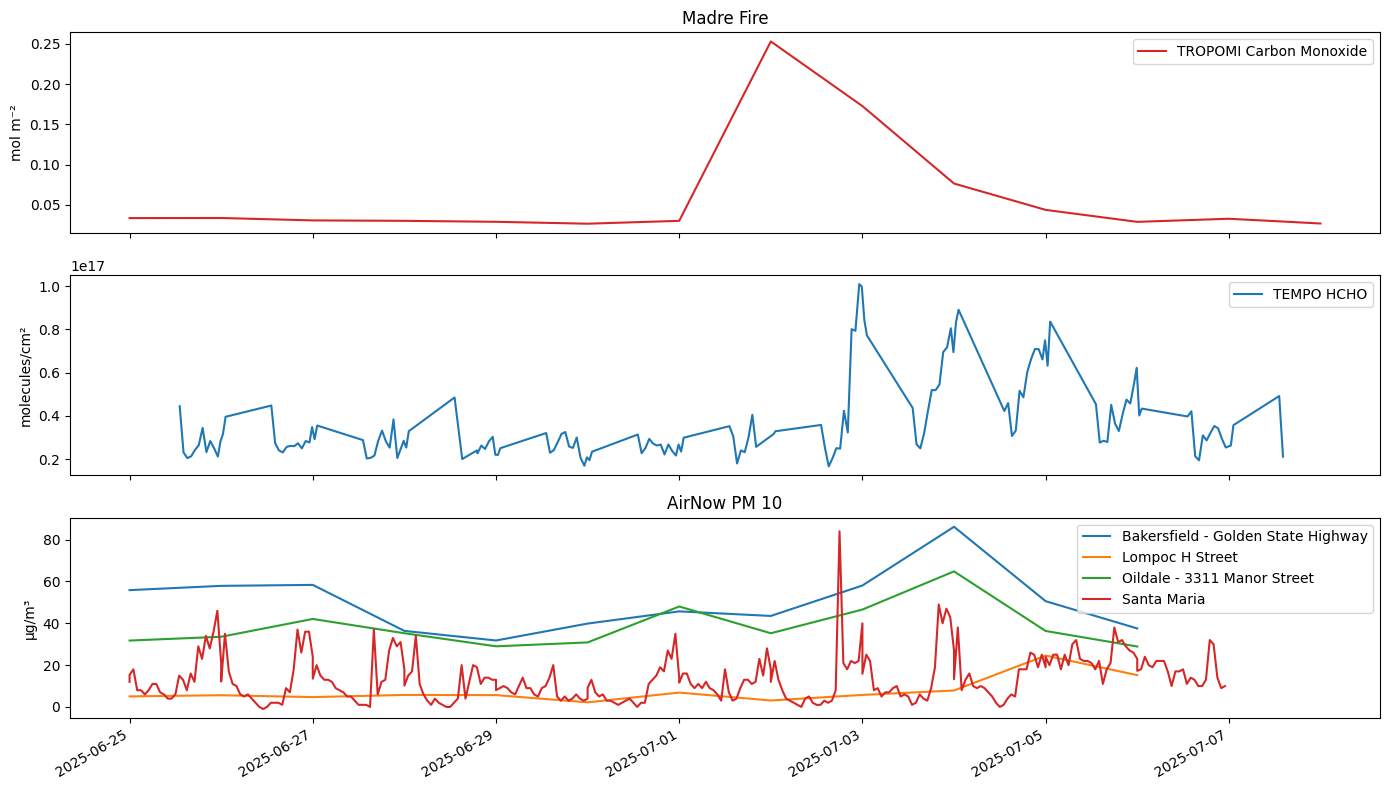

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Plot CO
ax1.plot(pd.to_datetime(co_timesteps), co_values, label="TROPOMI Carbon Monoxide", color="tab:red")
ax1.set_ylabel("mol m⁻²")
ax1.legend()

# Plot HCHO
ax2.plot(pd.to_datetime(hcho_timesteps), hcho_values, label="TEMPO HCHO", color="tab:blue")
ax2.set_ylabel("molecules/cm²")
ax2.legend()

# Plot AirNow PM10 data grouped by platform
for platform, group in madre_airnow_df[["pm10", "platform"]].dropna(axis=0).groupby("platform")["pm10"]:
    ax3.plot(group.index, group.values, label=platform)
ax3.set_ylabel("µg/m³")
ax3.set_title("AirNow PM 10")
ax3.legend(loc="upper right")

# Format x-axis dates nicely
fig.autofmt_xdate()
ax1.set_title("Madre Fire")
plt.tight_layout()

## Additional Examples

### CANOE NO2

In [26]:
CANOE_NO2_df = data_request("Dynamic-Aviation-B200--CANOE-NO2", datetime(2025,6,1), datetime(2025,7,3), '-80,38,-70,40')
CANOE_NO2_df['no2'] = CANOE_NO2_df['no2'].replace(-9.999, np.nan)
CANOE_NO2_df

,latitude,longitude,no2,gps_altitude,provider,platform
time,,,,,,
2025-06-22 18:39:40+00:00,38.000357,-75.464425,1.156,518.388600,SARP,Dynamic-Aviation-B200--CANOE-NO2
2025-06-22 18:39:41+00:00,38.001259,-75.464148,0.985,517.718040,SARP,Dynamic-Aviation-B200--CANOE-NO2
2025-06-22 18:39:42+00:00,38.002159,-75.463874,1.011,516.989568,SARP,Dynamic-Aviation-B200--CANOE-NO2
2025-06-22 18:39:43+00:00,38.003058,-75.463601,1.186,516.181848,SARP,Dynamic-Aviation-B200--CANOE-NO2
2025-06-22 18:39:44+00:00,38.003955,-75.463332,1.004,515.261352,SARP,Dynamic-Aviation-B200--CANOE-NO2
...,...,...,...,...,...,...
2025-06-25 17:15:54+00:00,38.356471,-75.881334,NaN,34.704528,SARP,Dynamic-Aviation-B200--CANOE-NO2
2025-06-25 17:15:55+00:00,38.356705,-75.882189,NaN,34.707576,SARP,Dynamic-Aviation-B200--CANOE-NO2
2025-06-25 17:15:56+00:00,38.356940,-75.883046,NaN,34.616136,SARP,Dynamic-Aviation-B200--CANOE-NO2


In [27]:
dataset_name = "TEMPO_NO2_L3_V03"
start_time = datetime(2025,6,22)
end_time = datetime(2025,6,25)
bounding_box = f'{CANOE_NO2_df["longitude"].min()},{CANOE_NO2_df["latitude"].min()},{CANOE_NO2_df["longitude"].max()},{CANOE_NO2_df["latitude"].max()}'
    
params = {
    'ds': dataset_name,
    'b': bounding_box,
    'startTime': start_time.strftime('%Y-%m-%dT%H:%M:%SZ'),
    'endTime': end_time.strftime('%Y-%m-%dT%H:%M:%SZ'),
}

response = requests.get("https://ideas-digitaltwin.jpl.nasa.gov/nexus/timeAvgMapSpark",
             params=params)

response_data = response.json()

records = [
    {'lat': data['lat'], 'lon': data['lon'], 'mean': data['mean']}
    for row in response_data['data']
    for data in row
]

# Create DataFrame
temp_no2_df = pd.DataFrame(records)

temp_no2_df

,lat,lon,mean
0,38.009998,-76.910004,1.139521e+15
1,38.009998,-76.890007,1.192359e+15
2,38.009998,-76.870010,1.328370e+15
3,38.009998,-76.850014,1.488795e+15
4,38.009998,-76.830017,1.571076e+15
...,...,...,...
7465,39.650036,-75.210289,3.356676e+15
7466,39.650036,-75.190292,3.245455e+15
7467,39.650036,-75.170296,3.123057e+15
7468,39.650036,-75.150299,3.101266e+15


In [ ]:
canoe_df = CANOE_NO2_df.dropna()
# Create base map centered on flight path
lat_center = canoe_df['latitude'].mean()
lon_center = canoe_df['longitude'].mean()
m = folium.Map(location=[lat_center, lon_center], zoom_start=7, tiles="cartodbpositron")

# Normalize NO₂ for coloring
colors = canoe_df['no2'].clip(0, .75).tolist()  # cap at 5 ppb for scale
coords = canoe_df[['latitude', 'longitude']].values.tolist()

# Add a colored flight track line
folium.ColorLine(positions=coords, colors=colors, colormap=['blue', 'yellow', 'red'], weight=5, opacity=0.8).add_to(m)

# Add a color scale legend
colormap = LinearColormap(['blue', 'yellow', 'red'], vmin=0, vmax=.75)
colormap.caption = "CANOE NO₂ (ppb)"
colormap.add_to(m)
m